In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.model_selection import GridSearchCV

In [100]:


df = pd.read_csv(
    r"C:\Users\M.Durga Prasad\OneDrive\Desktop\Customer_Churn_Prediction\data\processed\customer_churn_cleaned.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df['churn_encoded'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [111]:
print(X.shape)
print(y.shape)

(7043, 19)
(7043,)


In [112]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
encoder = OneHotEncoder(handle_unknown='ignore', drop='first')

In [33]:
preprocessor = ColumnTransformer(transformers=[('cat', encoder, categorical_cols), ('num', StandardScaler(), numerical_cols)])

In [34]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [35]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(5634, 30)
(1409, 30)


In [36]:
# logisticRegression
model = LogisticRegression(max_iter=2000)

In [37]:
model.fit(X_train_processed, y_train)

LogisticRegression(max_iter=2000)

In [38]:
y_pre = model.predict(X_test_processed)
print(y_pre[:10])

[0 1 0 0 0 1 0 0 0 0]


In [39]:
print('Actual:', y_test.values[:10])
print('Predicted', y_pre[:10])

Actual: [0 0 0 0 0 0 0 0 0 1]
Predicted [0 1 0 0 0 1 0 0 0 0]


In [41]:
# accuracy score
accuracy = accuracy_score(y_test, y_pre)
print(accuracy)

0.8069552874378992


In [43]:
print(classification_report(y_test, y_pre))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [45]:
cm = confusion_matrix(y_test, y_pre)
print(cm)

[[927 108]
 [164 210]]


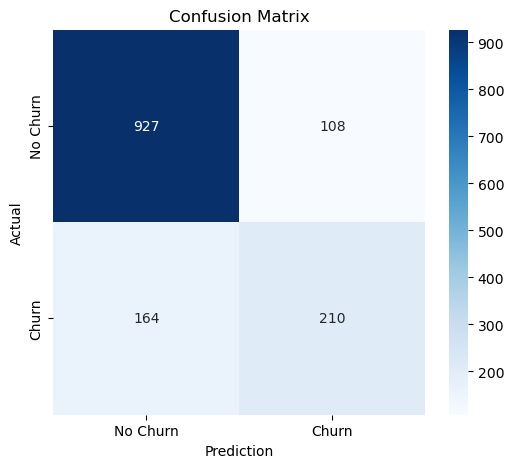

In [49]:
plt.figure(figsize=(6,5))

sns.heatmap(cm, annot = True , fmt ='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], ytickslabels=['No Churn', 'Churn'])

plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [61]:
y_prob = model.predict_proba(X_test_processed)[:, 1]
print(y_prob[:10])
print("y_test shape:", y_test.shape)
print("y_prob shape:", y_prob.shape)

[0.0458386  0.68375823 0.06007238 0.39936455 0.02161438 0.60226845
 0.44714269 0.12890608 0.00289668 0.39605096]
y_test shape: (1409,)
y_prob shape: (1409,)


In [62]:
print('y_test shape', y_test.shape)
print('Prob shape', y_prob.shape)
print('Unique y_prob', y_test.unique())
print('first 10', y_prob[:10])

y_test shape (1409,)
Prob shape (1409,)
Unique y_prob [0 1]
first 10 [0.0458386  0.68375823 0.06007238 0.39936455 0.02161438 0.60226845
 0.44714269 0.12890608 0.00289668 0.39605096]


In [65]:
roc_auc = roc_auc_score(y_test, y_prob)
print('ROC-AUC:', roc_auc)

ROC-AUC: 0.8421710713270816


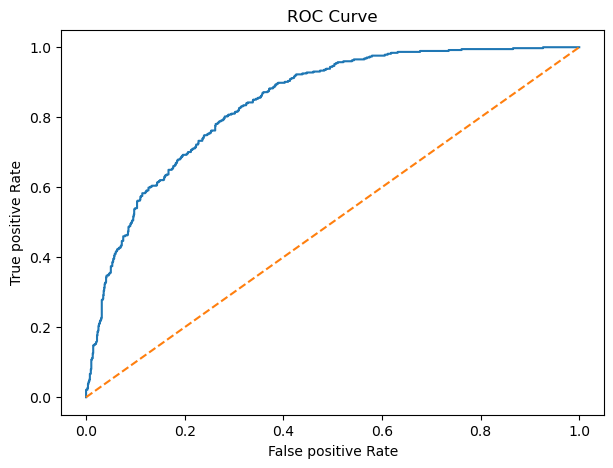

In [68]:
# ROC CURVE
fpr, tpr, threshold = roc_curve(y_test, y_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC= {roc_auc:.2f})')
plt.plot([0,1],[0,1], linestyle='--', label = 'Random Guess')
plt.xlabel('False positive Rate')
plt.ylabel('True positive Rate')
plt.title('ROC Curve')
plt.show()

In [70]:
dt_model = DecisionTreeClassifier(random_state = 42)

In [71]:
dt_model.fit(X_train_processed, y_train)

DecisionTreeClassifier(random_state=42)

In [72]:
dt_y_pred = dt_model.predict(X_test_processed)

print(dt_y_pred[:10])

[0 1 0 1 0 0 0 0 0 0]


In [73]:
print('Actual values',y_test.values[:10])
print('Predicted values',dt_y_pred[:10])

Actual values [0 0 0 0 0 0 0 0 0 1]
Predicted values [0 1 0 1 0 0 0 0 0 0]


In [107]:
dt_accuracy = accuracy_score(y_test, dt_y_pred)
print('Decision Tree Accuracy:', dt_accuracy)

Decision Tree Accuracy: 0.7267565649396736


In [80]:
print(classification_report(y_test, dt_y_pred))

              precision    recall  f1-score   support

           0       0.81      0.82      0.81      1035
           1       0.49      0.48      0.48       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



In [81]:
cm_dt = confusion_matrix(y_test, dt_y_pred)
print(cm_dt)

[[846 189]
 [196 178]]


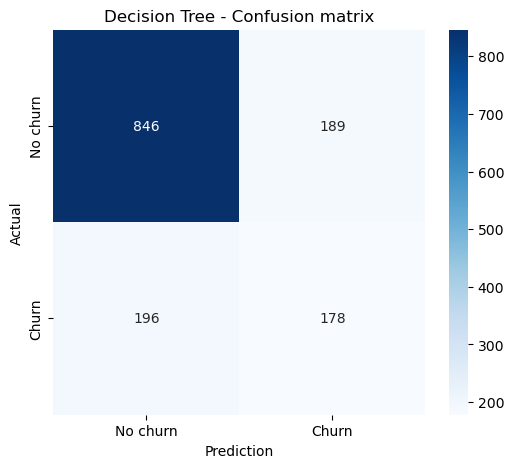

In [83]:
plt.figure(figsize=(6,5))

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['No churn', 'Churn'], yticklabels=['No churn', 'Churn'])

plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.title('Decision Tree - Confusion matrix')
plt.show()

In [85]:
dt_y_prob = dt_model.predict_proba(X_test_processed)[:, 1]
print(dt_y_prob[:10])

[0. 1. 0. 1. 0. 0. 0. 0. 0. 0.]


In [86]:
dt_roc_auc = roc_auc_score(y_test, dt_y_prob)
print('Decision Tree ROC_AUC_SCORE', dt_roc_auc)

Decision Tree ROC_AUC_SCORE 0.646157224418094


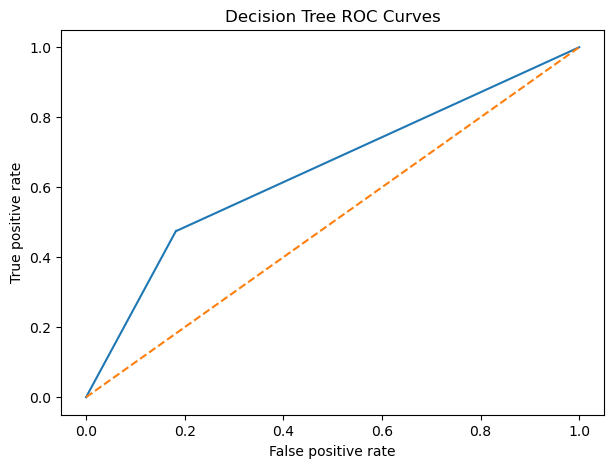

In [87]:
dt_fpr, dt_tpr, dt_threshold = roc_curve(y_test, dt_y_prob)
plt.figure(figsize=(7,5))
plt.plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC = {dt_roc_auc:.2f})')
plt.plot([0,1],[0,1], linestyle='--' , label='Random Guess')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Decision Tree ROC Curves')
plt.show()

In [103]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
print(rf_model)

RandomForestClassifier(random_state=42)


In [104]:
rf_model.fit(X_train_processed, y_train)
rf_y_pred = rf_model.predict(X_test_processed)
print(rf_y_pred[:10])

[0 1 0 0 0 0 0 0 0 1]


In [113]:
rf_accuracy = accuracy_score(y_test, rf_y_pred)
print('Rondam Forest Classifier Accuracy:', rf_accuracy)

Rondam Forest Classifier Accuracy: 0.7927608232789212


In [116]:
print('Random Forest Classification Report')
print(classification_report(y_test, rf_y_pred))

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [117]:
rf_cm = confusion_matrix(y_test, rf_y_pred)
print(rf_cm)

[[927 108]
 [184 190]]


In [119]:
rf_proba = rf_model.predict_proba(X_test_processed)[:, 1]
rf_roc_auc = roc_auc_score(y_test, rf_proba)
print('Random Forest (ROC_AUC SCORE):', rf_roc_auc)

Random Forest (ROC_AUC SCORE): 0.8204409827171976


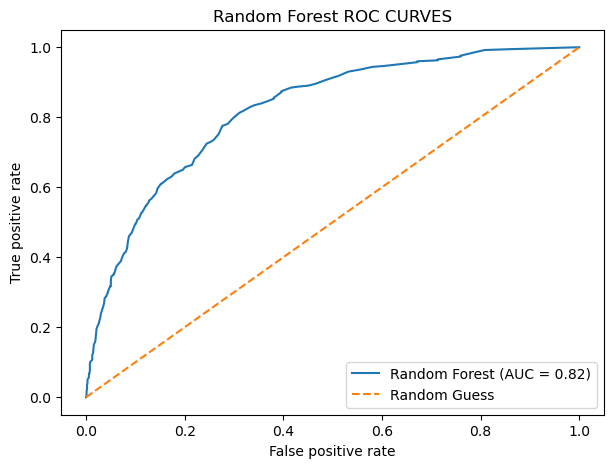

In [128]:
## rf_fpr, rf_tpr, rf_thresholds = roc_curve(y_test, rf_proba)

rf_fpr, rf_tpr, rf_thresholds = roc_curve(y_test, rf_proba)

plt.figure(figsize=(7, 5))

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f'Random Forest (AUC = {rf_roc_auc:.2f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Guess'
)

plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Random Forest ROC CURVES')
plt.legend()
plt.show()

In [134]:
# Logistic Regression
lr_pred = model.predict(X_test_processed)
lr_prob = model.predict_proba(X_test_processed)[:, 1]

# Decision Tree
dt_pred = dt_model.predict(X_test_processed)
dt_prob = dt_model.predict_proba(X_test_processed)[:, 1]

# Random Forest
rf_pred = rf_model.predict(X_test_processed)
rf_prob = rf_model.predict_proba(X_test_processed)[:, 1]

# Create comparison table
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1-Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.807,0.660,0.561,0.607,0.842
1,Decision Tree,0.727,0.485,0.476,0.480,0.646
2,Random Forest,0.793,0.638,0.508,0.565,0.820


In [136]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

print(param_grid)

{'n_estimators': [100, 200, 300], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}


In [137]:
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print(rf_grid)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='roc_auc')


In [142]:
rf_grid.fit(X_train_processed, y_train)
print('Best Parametrs:')
print(rf_grid.best_params_)

Best Parametrs:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [143]:
best_rf_model = rf_grid.best_estimator_

print("Best Random Forest Model:")
print(best_rf_model)

Best Random Forest Model:
RandomForestClassifier(max_depth=10, min_samples_leaf=2, n_estimators=200,
                       random_state=42)


In [144]:
rf_tuned_pred = best_rf_model.predict(X_test_processed)

print('Tuned Random Forest:')
print(rf_tuned_pred[:10])

Tuned Random Forest:
[0 1 0 0 0 0 0 0 0 0]


In [145]:
rf_tuned_accuracy = accuracy_score(y_test, rf_tuned_pred)
print('Random Forest Tuned Accuracy:', rf_tuned_accuracy)

Random Forest Tuned Accuracy: 0.8069552874378992


In [146]:
rf_tuned_prob = best_rf_model.predict_proba(X_test_processed)[:, 1]

rf_tuned_roc_auc = roc_auc_score(y_test, rf_tuned_prob)

print("Tuned Random Forest ROC-AUC:", rf_tuned_roc_auc)


Tuned Random Forest ROC-AUC: 0.8436823477744194


In [147]:

print("Tuned Random Forest Classification Report:")
print(classification_report(y_test, rf_tuned_pred))

Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [148]:
rf_tuned_cm = confusion_matrix(y_test, rf_tuned_pred)

print("Tuned Random Forest Confusion Matrix:")
print(rf_tuned_cm)

Tuned Random Forest Confusion Matrix:
[[940  95]
 [177 197]]


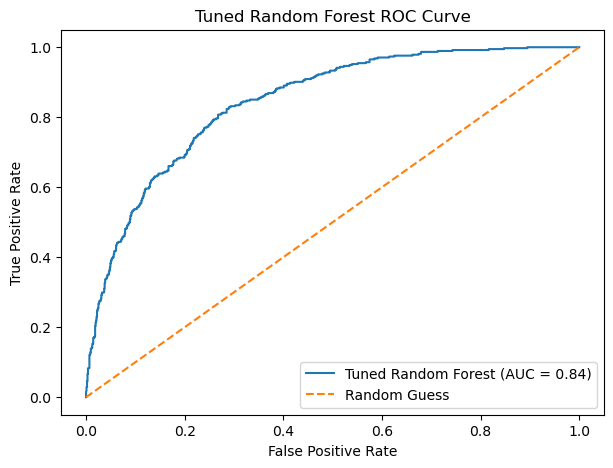

In [149]:
rf_tuned_fpr, rf_tuned_tpr, rf_tuned_thresholds = roc_curve(
    y_test,
    rf_tuned_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    rf_tuned_fpr,
    rf_tuned_tpr,
    label=f'Tuned Random Forest (AUC = {rf_tuned_roc_auc:.2f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Guess'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Tuned Random Forest ROC Curve')
plt.legend()

plt.show()

In [150]:
print(rf_tuned_prob[:20])

[0.00918783 0.77660816 0.07830763 0.35799027 0.01165262 0.48136418
 0.37718361 0.08801593 0.01578724 0.41641813 0.20126984 0.01560351
 0.20776933 0.65460037 0.17018727 0.10516246 0.02695874 0.62422527
 0.20309145 0.10496634]


In [151]:
threshold = 0.40

rf_tuned_pred_040 = (rf_tuned_prob >= threshold).astype(int)

print("Predictions using threshold 0.40:")
print(rf_tuned_pred_040[:20])

Predictions using threshold 0.40:
[0 1 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 0 0]


In [152]:
threshold_040_accuracy = accuracy_score(y_test, rf_tuned_pred_040)
threshold_040_precision = precision_score(y_test, rf_tuned_pred_040)
threshold_040_recall = recall_score(y_test, rf_tuned_pred_040)
threshold_040_f1 = f1_score(y_test, rf_tuned_pred_040)

print("Threshold: 0.40")
print("Accuracy :", threshold_040_accuracy)
print("Precision:", threshold_040_precision)
print("Recall   :", threshold_040_recall)
print("F1-Score :", threshold_040_f1)

Threshold: 0.40
Accuracy : 0.7842441447835344
Precision: 0.5845410628019324
Recall   : 0.6470588235294118
F1-Score : 0.6142131979695431


In [153]:
threshold_040_cm = confusion_matrix(y_test, rf_tuned_pred_040)

print("Confusion Matrix - Threshold 0.40:")
print(threshold_040_cm)

Confusion Matrix - Threshold 0.40:
[[863 172]
 [132 242]]


In [154]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (rf_tuned_prob >= threshold).astype(int)

    threshold_results.append({
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_test, y_pred_threshold),
        'Precision': precision_score(y_test, y_pred_threshold),
        'Recall': recall_score(y_test, y_pred_threshold),
        'F1-Score': f1_score(y_test, y_pred_threshold)
    })

threshold_comparison = pd.DataFrame(threshold_results)

threshold_comparison.round(3)

,Threshold,Accuracy,Precision,Recall,F1-Score
0,0.30,0.758,0.530,0.778,0.631
1,0.35,0.769,0.550,0.709,0.619
2,0.40,0.784,0.585,0.647,0.614
3,0.45,0.802,0.639,0.583,0.610
4,0.50,0.807,0.675,0.527,0.592
5,0.55,0.801,0.714,0.420,0.529
6,0.60,0.795,0.746,0.345,0.472


In [155]:
threshold = 0.40

rf_final_pred = (rf_tuned_prob >= threshold).astype(int)

print("First 20 predictions:")
print(rf_final_pred[:20])

First 20 predictions:
[0 1 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 0 0]


Confusion Matrix:
[[863 172]
 [132 242]]


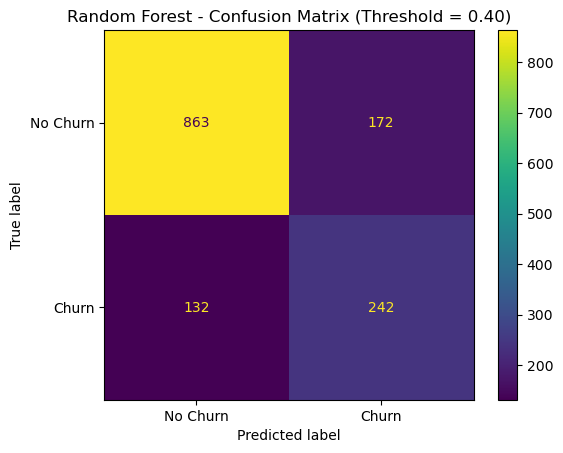

In [158]:
cm = confusion_matrix(y_test, rf_final_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Random Forest - Confusion Matrix (Threshold = 0.40)")
plt.show()

In [159]:
print("Classification Report - Random Forest (Threshold = 0.40)")
print(classification_report(
    y_test,
    rf_final_pred,
    target_names=["No Churn", "Churn"]
))

Classification Report - Random Forest (Threshold = 0.40)
              precision    recall  f1-score   support

    No Churn       0.87      0.83      0.85      1035
       Churn       0.58      0.65      0.61       374

    accuracy                           0.78      1409
   macro avg       0.73      0.74      0.73      1409
weighted avg       0.79      0.78      0.79      1409



In [161]:
final_model = Pipeline([('preprocessor', preprocessor),('model', best_rf_model)])
final_model.fit(X_train, y_train)
print('Final Model Pipeline Trained Successfully')

Final Model Pipeline Trained Successfully


In [162]:
final_proba = final_model.predict_proba(X_test)[:,1]
final_pre = (final_proba >= 0.40).astype(int)

print('Final Prediction', final_pre[:10])
print('Final Probabilities', final_proba[:10])

Final Prediction [0 1 0 0 0 1 0 0 0 1]
Final Probabilities [0.00918783 0.77660816 0.07830763 0.35799027 0.01165262 0.48136418
 0.37718361 0.08801593 0.01578724 0.41641813]


In [164]:
print("Final Model Performance (Threshold = 0.40)")
print("------------------------------------------")
print("Accuracy :", round(accuracy_score(y_test, final_pre), 3))
print("Precision:", round(precision_score(y_test, final_pre), 3))
print("Recall   :", round(recall_score(y_test, final_pre), 3))
print("F1-Score :", round(f1_score(y_test, final_pre), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, final_proba), 3))

Final Model Performance (Threshold = 0.40)
------------------------------------------
Accuracy : 0.784
Precision: 0.585
Recall   : 0.647
F1-Score : 0.614
ROC-AUC  : 0.844


In [165]:
import joblib

joblib.dump(
    final_model,
    "C:/Users/M.Durga Prasad/OneDrive/Desktop/Customer_Churn_Prediction/models/customer_churn_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


In [166]:
import joblib

loaded_model = joblib.load(
    "C:/Users/M.Durga Prasad/OneDrive/Desktop/Customer_Churn_Prediction/models/customer_churn_model.pkl"
)

print("Model loaded successfully!")
print(loaded_model)

Model loaded successfully!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
   

In [170]:
import pandas as pd

new_customer = pd.DataFrame([{
    'gender': 'Male',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 12,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 75.50,
    'TotalCharges': 906.00
}])

print(new_customer)

  gender  SeniorCitizen Partner Dependents  tenure PhoneService MultipleLines  \
0   Male              0     Yes         No      12          Yes            No   

  InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport  \
0     Fiber optic             No          Yes               No          No   

  StreamingTV StreamingMovies        Contract PaperlessBilling  \
0         Yes              No  Month-to-month              Yes   

      PaymentMethod  MonthlyCharges  TotalCharges  
0  Electronic check            75.5         906.0  


In [172]:
FINAL_THRESHOLD = 0.40

In [173]:
probability = loaded_model.predict_proba(new_customer)[:, 1]

prediction = (probability >= FINAL_THRESHOLD).astype(int)

In [174]:
probability = loaded_model.predict_proba(new_customer)[0, 1]

prediction = int(probability >= FINAL_THRESHOLD)

print("Churn Probability:", round(probability, 3))
print("Prediction:", prediction)

if prediction == 1:
    print("Result: Customer is likely to churn")
else:
    print("Result: Customer is likely to stay")

Churn Probability: 0.609
Prediction: 1
Result: Customer is likely to churn
